# Single-Layer Perceptron

## Nirjhor Deb Jeet

## 1. Part- 1( Based on class instraction)

### 1.1 Introduction:
The perceptron was created by Frank Rosenblatt in 1957. He was interested in how the human brain learns and wanted to create a simple model that could help computers learn in a similar way.


### 1.2 The story behind: 
Scientists knew that the human brain is made of neurons that

1. Receive information
2. 
•	Process
3. Decide whether to send a signal

Frank Rosenblatt wondered if a computer could copy this behavior. So he designed the perceptron as a very basic artificial neuron. It takes input values, combines them, and makes a yes or no decision. If the decision is wrong, it adjusts itself and tries again. This was a new idea at the time.gnal


### 1.3 A brief history:
1. 1957–1958: The perceptron is introduced and tested
2. 1960s: It gains attention as an early learning machine
3. Late 1960s: Researchers discover it has limitations and cannot solve complex problems
4. Later years: The idea is expanded into neural networks
5. Today, Modern AI systems are built using many perceptron-like units working together

These machines were powerful for their time but extremely basic compared to today’s laptops or smartphones.

### 1.4 Usability:
A perceptron is used for simple binary classification problems where data can be separated using a straight line. It is commonly applied in basic decision-making tasks such as yes/no predictions, pass/fail classification, or simple pattern recognition. Perceptrons are also mainly used for learning and teaching the fundamentals of machine learning.


### 1.5 Limitation:
A perceptron can only handle linearly separable data and does not work well with complex patterns. It supports only two output classes and cannot provide probability values. The model is sensitive to noise and is not suitable for solving real-world problems that require higher accuracy or non-linear decision boundaries.


### 1.6 Why does the Perceptron still matter?
The perceptron is important because it forms the foundation of modern neural networks. It introduces core ideas such as weights, bias, and learning through error correction. Understanding the perceptron helps in learning more advanced machine-learning and deep-learning models.


### 1.7 Code: Single-layer Perceptron with random parameters

In [8]:
pip install numpy

Note: you may need to restart the kernel to use updated packages.


In [9]:
pip install numpy matplotlib scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [10]:
pip install pandas

Note: you may need to restart the kernel to use updated packages.


Perceptron classification accuracy 1.0


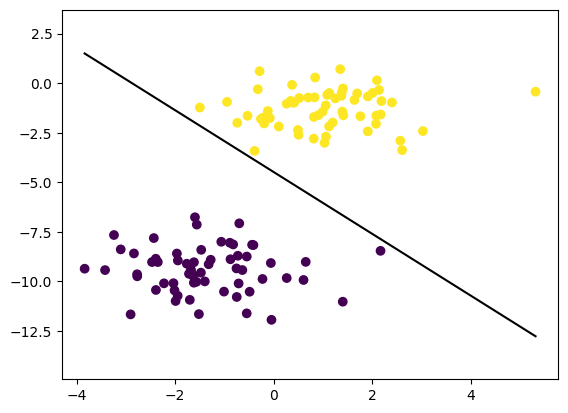

In [11]:
import numpy as np

#Random seed
np.random.seed(42)

#Activation function
def unit_step_func(x):
    return np.where(x > 0 , 1, 0)

class Perceptron:

    def __init__(self, learning_rate=0.01, n_iters=1000):
        self.lr = learning_rate
        self.n_iters = n_iters
        self.activation_func = unit_step_func
        self.weights = None
        self.bias = None

    #Get data shape
    def fit(self, X, y):
        n_samples, n_features = X.shape

        # initialize random parameters
        self.weights = np.random.randn(n_features)
        self.bias = np.random.randn()

        #Convert labels to 0 and 1
        y_ = np.where(y > 0, 1, 0)

        # Training loops
        for _ in range(self.n_iters):
            #The core equation: weighted sum + bias
            for idx, x_i in enumerate(X):
                linear_output = np.dot(x_i, self.weights) + self.bias
                #Turns the number into 0 or 1
                y_predicted = self.activation_func(linear_output)

                # Perceptron update rule
                update = self.lr * (y_[idx] - y_predicted)
                self.weights += update * x_i
                self.bias += update


    #Making predictions
    def predict(self, X):
        linear_output = np.dot(X, self.weights) + self.bias
        y_predicted = self.activation_func(linear_output)
        return y_predicted


# Testing
if __name__ == "__main__":
    # Imports
    import matplotlib.pyplot as plt
    from sklearn.model_selection import train_test_split
    from sklearn import datasets

    def accuracy(y_true, y_pred):
        accuracy = np.sum(y_true == y_pred) / len(y_true)
        return accuracy

    #Create fake data
    X, y = datasets.make_blobs(
        n_samples=150, n_features=2, centers=2, cluster_std=1.05, random_state=2
    )
    #Split data
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=123
    )

    p = Perceptron(learning_rate=0.01, n_iters=1000)
    #Train and test
    p.fit(X_train, y_train)
    predictions = p.predict(X_test)

    #Then accuracy is calculated
    print("Perceptron classification accuracy", accuracy(y_test, predictions))

    fig = plt.figure()
    ax = fig.add_subplot(1, 1, 1)
    plt.scatter(X_train[:, 0], X_train[:, 1], marker="o", c=y_train)

    x0_1 = np.amin(X_train[:, 0])
    x0_2 = np.amax(X_train[:, 0])

    x1_1 = (-p.weights[0] * x0_1 - p.bias) / p.weights[1]
    x1_2 = (-p.weights[0] * x0_2 - p.bias) / p.weights[1]

    ax.plot([x0_1, x0_2], [x1_1, x1_2], "k")

    ymin = np.amin(X_train[:, 1])
    ymax = np.amax(X_train[:, 1])
    ax.set_ylim([ymin - 3, ymax + 3])

    plt.show()

### 1.8 Model Output Explanation:
The figure above shows the results of the perceptron classifier after training on a linearly separable dataset. Each point represents a data sample, with different colors indicating the two classes. The straight black line represents the decision boundary learned by the perceptron.
The reported classification accuracy of 1.0 (100%) indicates that the perceptron successfully learned a linear boundary that separates the two classes without error. This outcome demonstrates how a perceptron performs well when the data is linearly separable. It also visually illustrates one of the key strengths of the perceptron model: its ability to find a simple linear separation between classes through iterative weight and bias updates.


## 2 Part- 2( Based on written documents)

2.1 Write code using a procedural programming language for a generic single-layer perceptron network. The program
should provide the flexibility to incorporate the following:
- Any number of input and output nodes
- Continuum of fully-connected networks and partially-connected networks
    - Provision for the user to provide:
    - Network configuration information,
    - Learning rate, and
    - Location of training and testing data sets
through a parameter file that can be passed to the executable
- Program should provide constant feedback to the user in terms of network performance during training and
execution
The code will be tested against different data sets.

In [12]:
import json

config = {
    "learning_rate": 0.01,
    "epochs": 50,
    "train_data_path": "train.csv",
    "test_data_path": "test.csv",
    "n_inputs": 4,
    "n_outputs": 1,
    "connectivity": "full"
}

with open("config.json", "w", encoding="utf-8") as f:
    json.dump(config, f, indent=4)

print("config.json created successfully!")

config.json created successfully!


In [13]:
import numpy as np
import pandas as pd

# -----------------------------
# SETTINGS (Modify if needed)
# -----------------------------
n_inputs = 4
n_train_samples = 200
n_test_samples = 50

np.random.seed(42)

# -----------------------------
# Generate Training Data
# -----------------------------
X_train = np.random.randn(n_train_samples, n_inputs)

# Linearly separable target
y_train = (np.sum(X_train, axis=1) > 0).astype(int)

train_df = pd.DataFrame(
    np.column_stack((X_train, y_train)),
    columns=[f"x{i+1}" for i in range(n_inputs)] + ["y"]
)

train_df.to_csv("train.csv", index=False)

# -----------------------------
# Generate Testing Data
# -----------------------------
X_test = np.random.randn(n_test_samples, n_inputs)
y_test = (np.sum(X_test, axis=1) > 0).astype(int)

test_df = pd.DataFrame(
    np.column_stack((X_test, y_test)),
    columns=[f"x{i+1}" for i in range(n_inputs)] + ["y"]
)

test_df.to_csv("test.csv", index=False)

print("train.csv and test.csv created successfully!")

train.csv and test.csv created successfully!


In [14]:
import json
import sys

# -----------------------------
# Activation Function
# -----------------------------
def step_function(x):
    return np.where(x >= 0, 1, 0)


# -----------------------------
# Load Configuration
# -----------------------------
def load_config(config_path):
    with open(config_path, 'r') as file:
        config = json.load(file)
    return config


# -----------------------------
# Load Dataset
# -----------------------------
def load_dataset(path, n_inputs, n_outputs):
    data = pd.read_csv(path)
    X = data.iloc[:, :n_inputs].values
    y = data.iloc[:, n_inputs:n_inputs+n_outputs].values
    return X, y


# -----------------------------
# Initialize Network
# -----------------------------
def initialize_network(n_inputs, n_outputs, connectivity, connectivity_matrix_path=None):
    
    weights = np.random.randn(n_inputs, n_outputs)
    bias = np.random.randn(n_outputs)

    if connectivity == "partial":
        connectivity_matrix = pd.read_csv(connectivity_matrix_path).values
        weights = weights * connectivity_matrix
    else:
        connectivity_matrix = np.ones((n_inputs, n_outputs))

    return weights, bias, connectivity_matrix


# -----------------------------
# Training Function
# -----------------------------
def train_perceptron(X, y, weights, bias, lr, epochs, connectivity_matrix):
    
    for epoch in range(epochs):
        total_error = 0
        
        for i in range(len(X)):
            
            linear_output = np.dot(X[i], weights) + bias
            prediction = step_function(linear_output)
            
            error = y[i] - prediction
            total_error += np.sum(np.abs(error))
            
            # Weight Update Rule
            weights += lr * np.outer(X[i], error) * connectivity_matrix
            bias += lr * error
        
        print(f"Epoch {epoch+1}/{epochs} - Total Error: {total_error}")
    
    return weights, bias


# -----------------------------
# Testing Function
# -----------------------------
def test_perceptron(X, y, weights, bias):
    
    correct = 0
    
    for i in range(len(X)):
        linear_output = np.dot(X[i], weights) + bias
        prediction = step_function(linear_output)
        
        if np.array_equal(prediction, y[i]):
            correct += 1
    
    accuracy = correct / len(X)
    print(f"\nTest Accuracy: {accuracy * 100:.2f}%")
    
    return accuracy


# -----------------------------
# Main Execution Block
# -----------------------------
def main(config_path):
    
    config = load_config(config_path)
    
    lr = config["learning_rate"]
    epochs = config["epochs"]
    n_inputs = config["n_inputs"]
    n_outputs = config["n_outputs"]
    train_path = config["train_data_path"]
    test_path = config["test_data_path"]
    connectivity = config["connectivity"]
    
    connectivity_matrix_path = config.get("connectivity_matrix_path", None)
    
    print("Loading datasets...")
    X_train, y_train = load_dataset(train_path, n_inputs, n_outputs)
    X_test, y_test = load_dataset(test_path, n_inputs, n_outputs)
    
    print("Initializing network...")
    weights, bias, connectivity_matrix = initialize_network(
        n_inputs, n_outputs, connectivity, connectivity_matrix_path
    )
    
    print("Starting training...")
    weights, bias = train_perceptron(
        X_train, y_train, weights, bias, lr, epochs, connectivity_matrix
    )
    
    print("Evaluating on test data...")
    test_perceptron(X_test, y_test, weights, bias)


# -----------------------------
# Run Program
# -----------------------------
if __name__ == "__main__":
    main("config.json")

Loading datasets...
Initializing network...
Starting training...
Epoch 1/50 - Total Error: 61.0
Epoch 2/50 - Total Error: 39.0
Epoch 3/50 - Total Error: 21.0
Epoch 4/50 - Total Error: 16.0
Epoch 5/50 - Total Error: 11.0
Epoch 6/50 - Total Error: 7.0
Epoch 7/50 - Total Error: 7.0
Epoch 8/50 - Total Error: 0.0
Epoch 9/50 - Total Error: 0.0
Epoch 10/50 - Total Error: 0.0
Epoch 11/50 - Total Error: 0.0
Epoch 12/50 - Total Error: 0.0
Epoch 13/50 - Total Error: 0.0
Epoch 14/50 - Total Error: 0.0
Epoch 15/50 - Total Error: 0.0
Epoch 16/50 - Total Error: 0.0
Epoch 17/50 - Total Error: 0.0
Epoch 18/50 - Total Error: 0.0
Epoch 19/50 - Total Error: 0.0
Epoch 20/50 - Total Error: 0.0
Epoch 21/50 - Total Error: 0.0
Epoch 22/50 - Total Error: 0.0
Epoch 23/50 - Total Error: 0.0
Epoch 24/50 - Total Error: 0.0
Epoch 25/50 - Total Error: 0.0
Epoch 26/50 - Total Error: 0.0
Epoch 27/50 - Total Error: 0.0
Epoch 28/50 - Total Error: 0.0
Epoch 29/50 - Total Error: 0.0
Epoch 30/50 - Total Error: 0.0
Epoch 31/

2.2 The study of the single-layer perceptron presented in the class is in the context of the McCulloh-Pitts model of a neuron. The nonlinear element of this model is represented by a hard limiter as its output end. It would be tempting to think that we can do better (than classification just linearly separable patterns) if we were to use a sigmoidal nonlinear element in
place of the hard limiter. Well, it turns out that the steady-state, decision-making characteristics of a single-layer perceptron are basically the same, regardless of whether we use hard-limiting or soft-limiting (differentiable nonlinear transfer function) as the source of nonlinearity in the neural model (Shynk and Bershad, 1991, 1992; Shynk, 1990). We may therefore state formally that so long as we limit ourselves to the model of a neuron that consists of a linear combiner followed by a nonlinear element, then regardless of the form of nonlinearity used, a single-layer perceptron can perform pattern classification only on linearly separable patterns.
Justify/demonstrate the validity of the above thesis.

Justification of the Linear Separability Limitation of a Single-Layer Perceptron
The single-layer perceptron, analyzed within the framework of the McCulloh–Pitts neuron model, 
consists of a linear combiner followed by a nonlinear activation function. Mathematically, the 
perceptron computes
[y = f(w^T x + b)]
where (x) is the input vector, (w) is the weight vector, (b) is the bias, and (f(·)) is a nonlinear
transfer function such as a hard limiter (step function) or a differentiable function like the 
sigmoid. The key question is whether replacing the hard limiter with a smooth nonlinear function 
enhances the perceptron’s ability to classify nonlinearly separable patterns.
The key point is that the perceptron's decision boundary is defined solely by the linear expression
( w^T x + b = 0 ). This equation describes a hyperplane in the input space: a line in two dimensions,
a plane in three dimensions, and a hyperplane in higher dimensions. The nonlinear activation 
function does not change this boundary; it only alters the numerical output after the linear 
combination has been calculated.
In the case of a hard limiter, classification changes when ( w^T x + b ) crosses zero. For a sigmoid
activation, classification usually happens when the output crosses 0.5. However, the sigmoid equals 
0.5 exactly when its argument is zero, meaning that the decision boundary remains ( w^T x + b = 0 ).
Therefore, whether the nonlinearity is hard-limiting or soft-limiting, the geometric structure of 
the classifier stays the same: a single hyperplane separating the input space into two half-spaces.
This limitation means the perceptron can only correctly classify linearly separable datasets. 
A well-known example is the XOR problem, where no single straight line can separate the two classes 
in the input plane. Because the perceptron creates only one hyperplane, it cannot solve XOR or other
nonlinearly separable classification problems. Changing the activation function doesn't add more 
decision boundaries or nonlinear feature transformations; it only reshapes the output scale.
Formally, because the model consists of a linear transformation followed by a pointwise nonlinearity,
the classification regions remain convex half-spaces. Nonlinearly separable patterns require 
multiple hyperplanes or nonlinear transformations of the input space, which necessitate hidden 
layers. Therefore, as long as the neuron model is limited to a single linear combiner with any 
nonlinear activation function, the steady-state decision-making characteristics stay the same: the 
single-layer perceptron can only classify patterns that are linearly separable.
This supports the idea that choosing between hard-limiting and soft-limiting nonlinearities does 
not increase the representational capacity of a single-layer perceptron.

2.3 The perceptron may be used to perform numerous logic functions. Demonstrate the implementation of the binary logic
functions AND, OR, and COMPLEMENT. However, a basic limitation of the perceptron is that it cannot implement the
EXCLUSIVE OR function. Justify/demonstrate the validity of this limitation.

A single-layer perceptron consists of a linear combination followed by a nonlinear activation function, typically a step function. The output is calculated as:

y = f(w1x1 + w2x2 + b)

where x1 and x2 are binary inputs (0 or 1), w1 and w2 are weights, b is the bias, and f(.) is a hard-limiting step function.
1. AND Function
Truth Table:
x1  x2  AND
0   0   0
0   1   0
1   0   0
1   1   1
Choose weights and bias as: w1 = 1, w2 = 1, b = -1.5. Decision rule: y = f(x1 + x2 - 1.5). Only when both inputs are 1 does the weighted sum exceed zero. Therefore, the perceptron correctly implements the AND function.
2. OR Function
Truth Table:
x1  x2  OR
0   0   0
0   1   1
1   0   1
1   1   1
Choose weights and biases as: w1 = 1, w2 = 1, b = -0.5. Decision rule: y = f(x1 + x2 - 0.5). If at least one input equals 1, the sum becomes positive. Therefore, the OR function is implemented.
3. COMPLEMENT (NOT) Function
Truth Table:
x   NOT x
0   1
1   0
Choose weight and bias as: w = -1, b = 0.5
Decision rule: y = f(-x + 0.5)

If x = 0, output is 1. If x = 1, output is 0. Thus, the perceptron realizes the NOT function.
Limitation: The XOR Function
Truth Table:
x1  x2  XOR
0   0   0
0   1   1
1   0   1
1   1   0
The XOR function is not linearly separable. If plotted in a two-dimensional space, the points (0,1) and (1,0) belong to class 1, while (0,0) and (1,1) belong to class 0. No single straight line can separate these classes. A perceptron defines a decision boundary of the form w1x1 + w2x2 + b = 0, which represents a single straight line. Since XOR requires more than one linear boundary, a single-layer perceptron cannot implement XOR. Therefore, while AND, OR, and NOT are linearly separable and can be implemented by a perceptron, XOR cannot be realized without introducing at least one hidden layer.

### Reference:
1. https://en.wikipedia.org/wiki/Perceptron
2. https://www.youtube.com/watch?v=aOEoxyA4uXU